In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error



In [51]:
# Load the dataset
tesla_data = pd.read_csv('tesla-stock-price.csv')

In [53]:
# Display the first few rows of the dataset
data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [55]:
data.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [57]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [59]:
data.head(5)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [61]:
data.shape

(150, 6)

In [63]:
data.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [67]:
numeric_data = data.select_dtypes(include=[float, int])

# Calculate Descriptive Statistics
mean_value = numeric_data.mean()
median_value = numeric_data.median()
mode_value = numeric_data.mode().iloc[0]  # mode may return multiple values
variance_value = numeric_data.var()
std_deviation_value = numeric_data.std()

# Print the results
print(f"Mean:\n{mean_value}\n")
print(f"Median:\n{median_value}\n")
print(f"Mode:\n{mode_value}\n")
print(f"Variance:\n{variance_value}\n")
print(f"Standard Deviation:\n{std_deviation_value}\n")

Mean:
Id               75.500000
SepalLengthCm     5.843333
SepalWidthCm      3.054000
PetalLengthCm     3.758667
PetalWidthCm      1.198667
dtype: float64

Median:
Id               75.50
SepalLengthCm     5.80
SepalWidthCm      3.00
PetalLengthCm     4.35
PetalWidthCm      1.30
dtype: float64

Mode:
Id               1.0
SepalLengthCm    5.0
SepalWidthCm     3.0
PetalLengthCm    1.5
PetalWidthCm     0.2
Name: 0, dtype: float64

Variance:
Id               1887.500000
SepalLengthCm       0.685694
SepalWidthCm        0.188004
PetalLengthCm       3.113179
PetalWidthCm        0.582414
dtype: float64

Standard Deviation:
Id               43.445368
SepalLengthCm     0.828066
SepalWidthCm      0.433594
PetalLengthCm     1.764420
PetalWidthCm      0.763161
dtype: float64



array([[<Axes: title={'center': 'Id'}>,
        <Axes: title={'center': 'SepalLengthCm'}>],
       [<Axes: title={'center': 'SepalWidthCm'}>,
        <Axes: title={'center': 'PetalLengthCm'}>],
       [<Axes: title={'center': 'PetalWidthCm'}>, <Axes: >]], dtype=object)

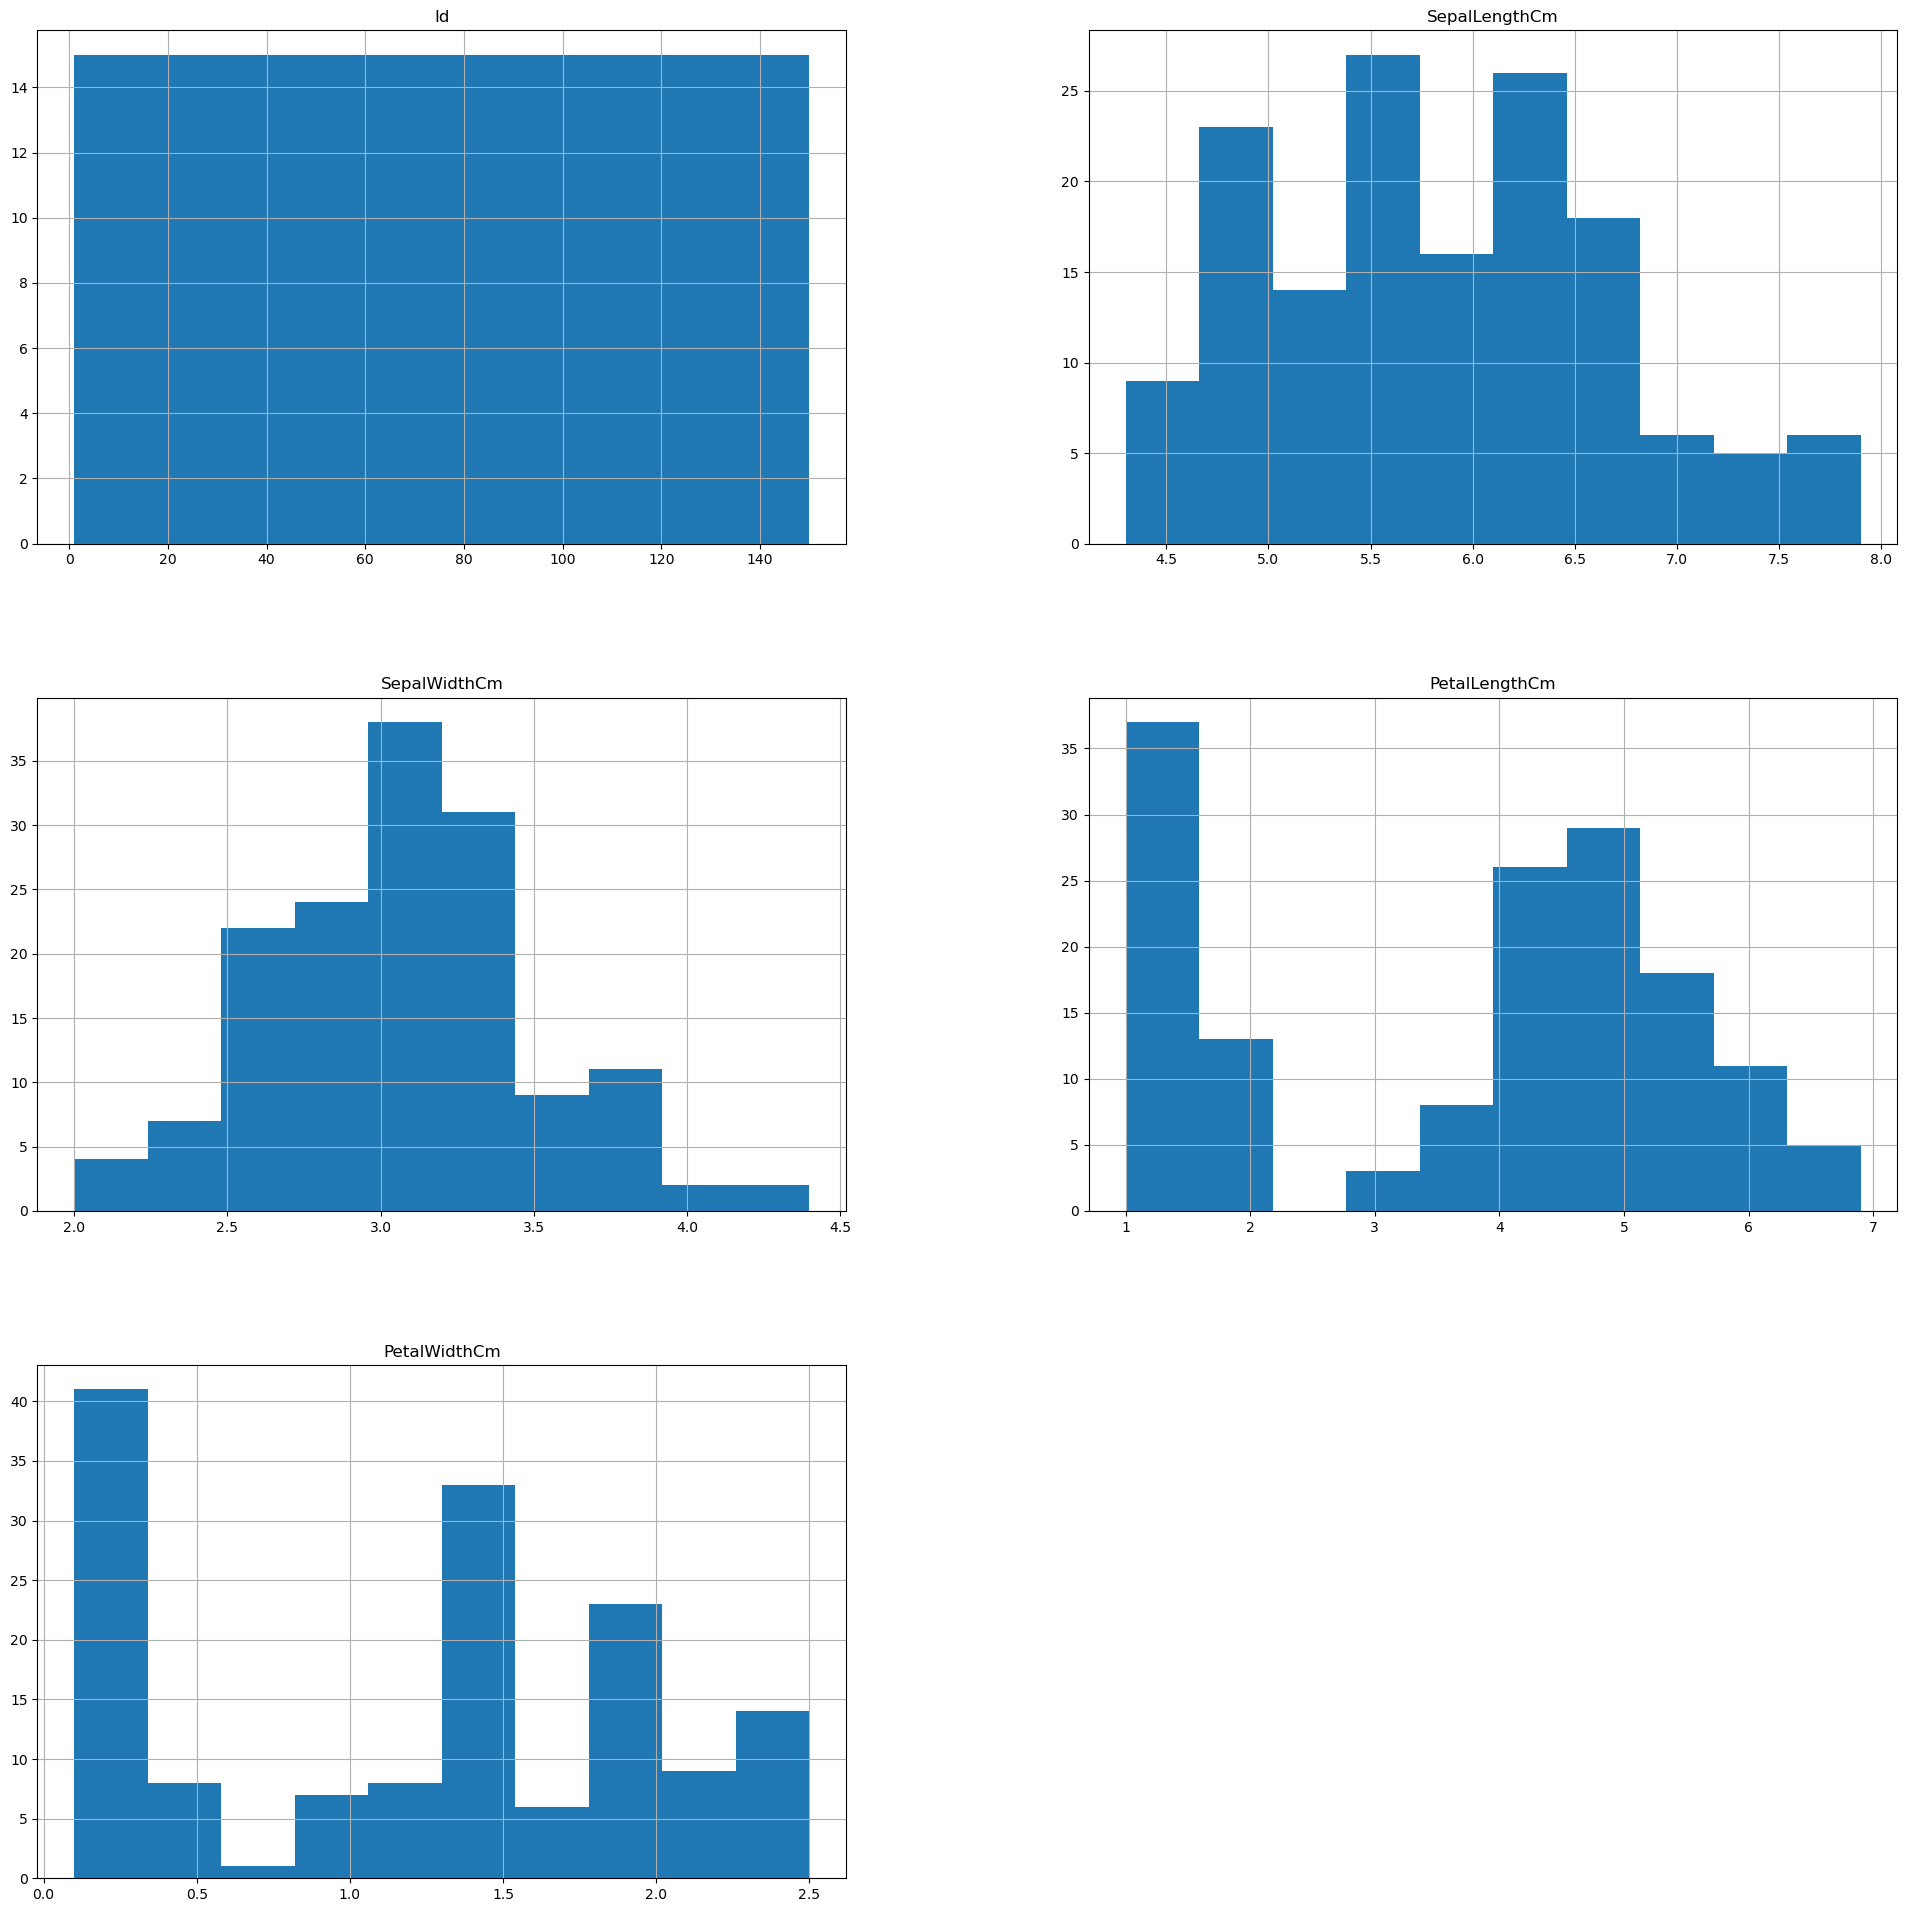

In [69]:
data.hist(figsize=(24,24))

In [73]:
print(data.columns)


Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')


In [75]:
data.columns = data.columns.str.strip()


In [77]:
print(data.columns)


Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')


In [79]:
# Define the plot size and orientation
plt.figure(figsize=(23, 10))

# Create a box plot showing Precipitation across different Years
ax = sns.boxplot(x='Year', y='Precipitation', data=data, width=0.8, palette="Set3")

# Set the labels and title
ax.set_xlabel('Year', fontsize=20)
ax.set_ylabel('Precipitation (mm)', fontsize=20)
ax.set_title('Annual Precipitation Distribution by Year', fontsize=25)

# Display the plot
plt.show()

ValueError: Could not interpret input 'Year'

<Figure size 2300x1000 with 0 Axes>